# Discrimination limit vs mixing angle (quasi-degenerate regime)

**Counting axions with IAXO** — B. Grinstein, C. Miró, P. Quílez (arXiv:2606.XXXXX). Unbinned likelihood analysis.

Discovery limits for two quasi-degenerate axions as a function of the mixing angle
$\varphi = \pi/4,\ \pi/8,\ \pi/16,\ \pi/32$, at fixed energy resolution
$\omega_{\rm res} = 100$ eV.

Analytic envelopes:
- small $\sqrt{\Delta m_{21}^2}$: $g^{\rm dis}_{a\gamma} \propto 1/\sin 2\varphi$
- large $\sqrt{\Delta m_{21}^2}$ (cosine averaged out): $g^{\rm dis}_{a\gamma} \propto (2 - \sin^2 2\varphi)^{1/4}/\sin 2\varphi$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

from iaxo_params import omega_min, omega_max, setup_plot_style
from conversion_prob import dN_domega
from test_statistic import compute_discovery_limit

## Parameters

In [2]:
E_res_keV = 0.1           # Energy resolution [keV]
n_uniform = 80000         # Grid points

# Dm2 scan range (two segments: dense up to 3e-6 eV, sparse to 6e-6 eV)
delta_m2_min = (4e-9)**2     # eV^2
delta_m2_maxmed = (3e-6)**2  # eV^2
delta_m2_max = (6e-6)**2     # eV^2
n_dm2 = 120
n_dm22 = 5

delta_m2_vals = np.append(
    np.logspace(np.log10(delta_m2_min), np.log10(delta_m2_maxmed), n_dm2),
    np.logspace(np.log10(delta_m2_maxmed), np.log10(delta_m2_max), n_dm22))
sqrt_dm2 = np.sqrt(delta_m2_vals)

# Load CAST exclusion and IAXO projection
data = np.loadtxt('input_data/CAST_exclusion.dat')
sqrt_dm2_data = data[:, 0]  # sqrt(Delta_m21^2) [eV]
g_CAST = data[:, 1]         # g exclusion CAST [GeV^-1]
# g_IAXO = data[:, 2]         # g projection IAXO [GeV^-1]

#IAXO projection 
dataIAXO = np.loadtxt('input_data/IAXO_projection.dat')
sqrt_dm2_data = dataIAXO[:, 0]  # sqrt(Delta_m21^2) [eV]
g_IAXO = dataIAXO[:, 1]         # g projection IAXO [GeV^-1]

#IAXO+ projection 
dataIAXOp = np.loadtxt('input_data/IAXOplus_projection.dat')
sqrt_dm2_data = dataIAXOp[:, 0]  # sqrt(Delta_m21^2) [eV]
g_IAXOp = dataIAXOp[:, 1]         # g projection IAXO [GeV^-1]

from scipy.interpolate import interp1d
g_CAST_interp = interp1d(np.log10(sqrt_dm2_data), np.log10(g_CAST),
                         kind='linear', fill_value='extrapolate')

## Compute discovery limits for each mixing angle

In [3]:
phis       = [np.pi/4, np.pi/8, np.pi/16, np.pi/32]
phi_labels = [r'$\varphi = \pi/4$', r'$\varphi = \pi/8$',
              r'$\varphi = \pi/16$', r'$\varphi = \pi/32$']

# H0: single massless axion (phi-independent)
dN_H0 = lambda E: dN_domega(E, m1=0, m2=0)

g_discovery_phis = []
for phi in phis:
    print(f"\n--- phi = {phi:.4f} ({phi/np.pi:.4f} pi), E_res = {int(E_res_keV*1000)} eV ---")
    def make_H1_phi(dm2, p=phi):
        m2_eff = np.sqrt(dm2)
        return lambda E, m=m2_eff, ph=p: dN_domega(E, m1=0, m2=m, phi=ph, E_res_keV=E_res_keV)
    g_disc, _ = compute_discovery_limit(
        delta_m2_vals, make_H1_phi, dN_H0,
        E_res_keV=E_res_keV, n_uniform=n_uniform, verbose=True)
    g_discovery_phis.append(g_disc)

print("\nDone.")


--- phi = 0.7854 (0.2500 pi), E_res = 100 eV ---
  [1/125] mass = 1.60e-17
  [13/125] mass = 6.08e-17
  [25/125] mass = 2.31e-16
  [37/125] mass = 8.78e-16
  [49/125] mass = 3.34e-15
  [61/125] mass = 1.27e-14
  [73/125] mass = 4.82e-14
  [85/125] mass = 1.83e-13
  [97/125] mass = 6.96e-13
  [109/125] mass = 2.65e-12
  [121/125] mass = 9.00e-12

--- phi = 0.3927 (0.1250 pi), E_res = 100 eV ---
  [1/125] mass = 1.60e-17
  [13/125] mass = 6.08e-17
  [25/125] mass = 2.31e-16
  [37/125] mass = 8.78e-16
  [49/125] mass = 3.34e-15
  [61/125] mass = 1.27e-14
  [73/125] mass = 4.82e-14
  [85/125] mass = 1.83e-13
  [97/125] mass = 6.96e-13
  [109/125] mass = 2.65e-12
  [121/125] mass = 9.00e-12

--- phi = 0.1963 (0.0625 pi), E_res = 100 eV ---
  [1/125] mass = 1.60e-17
  [13/125] mass = 6.08e-17
  [25/125] mass = 2.31e-16
  [37/125] mass = 8.78e-16
  [49/125] mass = 3.34e-15
  [61/125] mass = 1.27e-14
  [73/125] mass = 4.82e-14
  [85/125] mass = 1.83e-13
  [97/125] mass = 6.96e-13
  [109/125] 

In [4]:
# -- SAVE results to file --
res_dir = 'results_data'
os.makedirs(res_dir, exist_ok=True)

for phi, g_disc in zip(phis, g_discovery_phis):
    phi_label = f'piover{np.pi/phi:.0f}'
    fname = f'Quasi_Angles_phi{phi_label}_Eres{int(E_res_keV*1000)}eV.txt'
    out = np.column_stack([sqrt_dm2, g_disc])
    header = ('Counting axions with IAXO (arXiv:2606.XXXXX) by B. Grinstein, C. Miro and P. Quilez\n'
              f'# Quasi-degenerate g_discovery vs sqrt_dm2 for mixing angle phi={phi:.6f} ({phi/np.pi:.4f}*pi)\n'
              f'# sqrt(Dm21^2) [eV]    g_discovery [GeV^-1]    E_res={int(E_res_keV*1000)} eV')
    np.savetxt(os.path.join(res_dir, fname), out, header=header)
    print(f'Saved {fname}')

Saved Quasi_Angles_phipiover4_Eres100eV.txt
Saved Quasi_Angles_phipiover8_Eres100eV.txt
Saved Quasi_Angles_phipiover16_Eres100eV.txt
Saved Quasi_Angles_phipiover32_Eres100eV.txt


In [3]:
# -- LOAD results from file (run this INSTEAD of the computation cell above) --
phis       = [np.pi/4, np.pi/8, np.pi/16, np.pi/32]
phi_labels = [r'$\varphi = \pi/4$', r'$\varphi = \pi/8$',
              r'$\varphi = \pi/16$', r'$\varphi = \pi/32$']

g_discovery_phis = []
for phi in phis:
    phi_label = f'piover{np.pi/phi:.0f}'
    fname = f'results_data/Quasi_Angles_phi{phi_label}_Eres{int(E_res_keV*1000)}eV.txt'
    d = np.loadtxt(fname)
    sqrt_dm2 = d[:, 0]
    g_discovery_phis.append(d[:, 1])
    print(f'Loaded {fname}: {len(d)} points')

Loaded results_data/Quasi_Angles_phipiover4_Eres100eV.txt: 125 points
Loaded results_data/Quasi_Angles_phipiover8_Eres100eV.txt: 125 points
Loaded results_data/Quasi_Angles_phipiover16_Eres100eV.txt: 125 points
Loaded results_data/Quasi_Angles_phipiover32_Eres100eV.txt: 125 points


## Plot

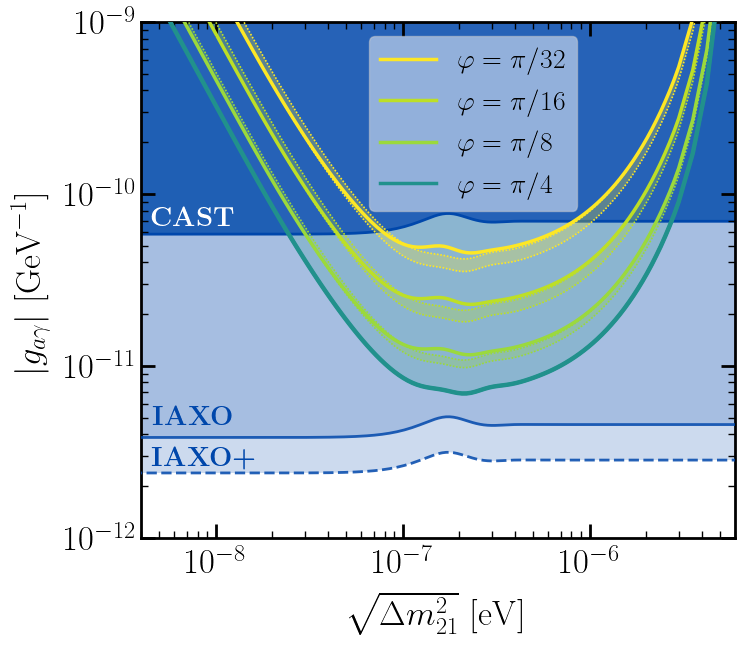

In [12]:
import matplotlib.patheffects as pe

colorsBounds = ["#0047AB", "#0047AB", "#0047AB"]

# Viridis greens: distinct from the YlOrRd discovery palette and the CAST blue
phi_colors = [plt.cm.viridis(v) for v in [0.5, 0.849, 0.899, 0.999]]

setup_plot_style()
fig, ax = plt.subplots(figsize=(8, 7))

# CAST exclusion
ax.loglog(sqrt_dm2_data, g_CAST, color=colorsBounds[2], lw=2, zorder=1)
ax.fill_between(sqrt_dm2_data, g_CAST, 1e-8, facecolor=colorsBounds[2], zorder=0.5, alpha=0.85)
ax.text(4.5e-9, 6.5e-11, r'{\bf CAST}', fontsize=20, color='w', zorder=1000)

# IAXO projection
ax.fill_between(sqrt_dm2_data, g_IAXO, g_CAST, facecolor=colorsBounds[1], zorder=0.05, alpha=0.35)
ax.loglog(sqrt_dm2_data, g_IAXO, colorsBounds[1], lw=2, ls='-', zorder=8, alpha=0.85)
ax.text(4.56e-9, 4.5e-12, r'{\bf IAXO}', fontsize=20, color=colorsBounds[1], zorder=1000)

# IAXO+ projection
ax.fill_between(sqrt_dm2_data, g_IAXOp, g_IAXO, facecolor=colorsBounds[0], zorder=0.05, alpha=0.2)
ax.loglog(sqrt_dm2_data, g_IAXOp, color=colorsBounds[0], lw=2, ls='--', zorder=8, alpha=0.85)
ax.text(4.5e-9, 2.6e-12, r'{\bf IAXO+}', fontsize=20, color=colorsBounds[0], zorder=1000)

# Analytic scaling envelopes
def Bestf_high(phi):
    u = np.sin(2*phi)**2
    return np.sin(2*phi) / (2 - u)**0.25

def Bestf_low(phi):
    return np.sin(2*phi)

g_ref = g_discovery_phis[0]  # phi = pi/4 reference

for phi, col in zip(phis, phi_colors):
    g_high = g_ref / Bestf_high(phi)
    g_low  = g_ref / Bestf_low(phi)
    ax.fill_between(sqrt_dm2, g_low, g_high, facecolor=col, alpha=0.25, zorder=1.5)
    ax.loglog(sqrt_dm2, g_high, color=col, lw=1.2, ls=(0, (1, 1)), zorder=3, alpha=1)
    ax.loglog(sqrt_dm2, g_low,  color=col, lw=1.2, ls=(0, (1, 1)), zorder=3, alpha=1)

# Numerical curves (solid, on top)
for g_disc, label, col in zip(g_discovery_phis, phi_labels, phi_colors):
    ax.loglog(sqrt_dm2, g_disc, color=col, lw=2.5, label=label, zorder=4, alpha=1)
ax.loglog(sqrt_dm2, g_discovery_phis[0], color=phi_colors[0], lw=3.2, zorder=4, alpha=1)

# Fill between phi=pi/4 curve and CAST
ax.fill_between(sqrt_dm2, g_discovery_phis[0], 10**g_CAST_interp(np.log10(sqrt_dm2)),
                facecolor=phi_colors[0], alpha=0.2, zorder=0.1)

ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$", labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$", labelpad=10)
ax.set_xlim([4e-9, 6e-6])
ax.set_ylim([1e-12, 1e-9])
ax.tick_params(axis='x', which='major', pad=8)
ax.tick_params(axis='x', which='minor', pad=8)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles[::-1], labels[::-1], fontsize=20, loc='upper right',
                framealpha=0.5, bbox_to_anchor=(0.7580, 0.999))
leg.set_zorder(20)
ax.set_zorder(100)
ax.set_axisbelow(False)

plt.tight_layout()

os.makedirs('plots', exist_ok=True)
fig.savefig('plots/Mixing-angle.pdf', bbox_inches='tight')
fig.savefig('plots/Mixing-angle.png', bbox_inches='tight')
plt.show()

# Optional: save directly into the Overleaf paper folder with the paper's figure names
save_overleaf = False
overleaf_dir = ('/home/pabloql/Cloud/Dropbox/Aplicaciones/Overleaf/'
                'Counting axions with helioscopes/plots')
if save_overleaf and os.path.isdir(overleaf_dir):
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(overleaf_dir, 'Mixing-angle.' + ext),
                    bbox_inches='tight')
    print('Saved to Overleaf: Mixing-angle.pdf/.png')